# Chapter 87 - Inspecting Embeddings

A token embedding table maps each vocabulary ID to a learned vector.

This chapter extracts that table, measures its geometry, and compares it with the same table before training.

## Learning goals

By the end of this chapter, you will be able to:

- extract and validate a trained token embedding table;

- retrieve one token's vector and verify embedding lookup shapes;

- compute vector norms and cosine similarities;

- find nearest-neighbor tokens while excluding the query token;

- compare trained neighbors with the model's saved initialization;

- project initial and trained embeddings into one shared 2D coordinate system; and

- interpret noisy character embeddings without making unsupported semantic claims.

## Terms and limits

A **token ID** is an integer assigned by a tokenizer.

An **embedding** is a learned vector used to represent one token ID at the input of the model.

An **embedding table** is a matrix with shape `[vocabulary size, embedding dimension]`.

**Cosine similarity** compares vector direction after accounting for length.

A **nearest neighbor** is a different token whose vector has high similarity under a chosen metric.

A **2D projection** maps high-dimensional vectors to two coordinates for plotting and necessarily discards information.

Tiny character models do not provide a strong test of semantic structure because characters are not words and this dataset supplies little training signal.

> A neighbor or visual cluster is an observation under one metric or projection.
>
> It is not proof that the model understands a linguistic category.

## Input embeddings are context-free parameters

Before Transformer layers run, the same token ID always retrieves the same token-embedding row.

Position embeddings are then added, and attention plus feedforward layers create context-dependent hidden states.

This chapter inspects only the input token table, not those later contextual representations.

## Build the same document holdout

Three public-domain excerpts form training data and a separate excerpt forms validation data.

The character tokenizer keeps the lookup between visible tokens and embedding rows direct.

In [1]:
import torch  # noqa: I001


training_documents = [
    """Alice was beginning to get very tired of sitting by her sister on the bank,
and of having nothing to do. Once or twice she had peeped into the book her
sister was reading, but it had no pictures or conversations in it, and what is
the use of a book, thought Alice, without pictures or conversation?""",
    """So she was considering in her own mind, as well as she could, for the hot day
made her feel very sleepy and stupid, whether the pleasure of making a daisy
chain would be worth the trouble of getting up and picking the daisies, when
suddenly a white rabbit with pink eyes ran close by her.""",
    """There was nothing so very remarkable in that; nor did Alice think it so very
much out of the way to hear the rabbit say to itself, Oh dear! Oh dear! I shall
be too late! But when the rabbit actually took a watch out of its waistcoat
pocket, and looked at it, and then hurried on, Alice started to her feet.""",
]
validation_text = """The rabbit hole went straight on like a tunnel for some way,
and then dipped suddenly down, so suddenly that Alice had not a moment to think
about stopping herself before she found herself falling down what seemed to be
a very deep well."""
training_text = "\n\n".join(training_documents)
characters = sorted(set(training_text))
character_to_id = {character: index for index, character in enumerate(characters)}
id_to_character = {index: character for character, index in character_to_id.items()}


def encode_text(text: str) -> list[int]:
    unknown_characters = sorted(set(text) - set(character_to_id))
    if unknown_characters:
        raise ValueError(f"Unknown characters: {unknown_characters!r}.")
    return [character_to_id[character] for character in text]


def token_to_token_id(token: str) -> int:
    return character_to_id[token]


def token_id_to_token(token_id: int) -> str:
    return id_to_character[token_id]


training_token_ids = torch.tensor(encode_text(training_text), dtype=torch.long)
validation_token_ids = torch.tensor(encode_text(validation_text), dtype=torch.long)
vocabulary_size = len(characters)

print("Vocabulary size:", vocabulary_size)
print("Training tokens:", training_token_ids.numel())
print("Validation tokens:", validation_token_ids.numel())

Vocabulary size: 35
Training tokens: 896
Validation tokens: 237


## Build reproducible GPT batches

An explicit random generator produces repeatable next-token windows.

In [2]:
def get_gpt_training_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    valid_starts = token_ids.numel() - context_length
    if token_ids.ndim != 1 or valid_starts < 1:
        raise ValueError(
            "Token stream must be one-dimensional and longer than context_length."
        )
    starts = torch.randint(0, valid_starts, (batch_size,), generator=generator)
    offsets = torch.arange(context_length)
    indexes = starts[:, None] + offsets[None, :]
    return token_ids[indexes], token_ids[indexes + 1]


test_generator = torch.Generator().manual_seed(87)
test_inputs, test_targets = get_gpt_training_batch(
    training_token_ids, 4, 16, test_generator
)
print("Input shape:", tuple(test_inputs.shape))
print("Target shift correct:", torch.equal(test_targets[:, :-1], test_inputs[:, 1:]))
assert torch.equal(test_targets[:, :-1], test_inputs[:, 1:])

Input shape: (4, 16)
Target shift correct: True


## Reuse the tiny GPT architecture

The dropout-aware architecture matches recent chapters, while attention inspection is omitted so embeddings remain the single new idea.

In [3]:
import math  # noqa: I001


class MultiHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError("Attention heads must divide the embedding dimension.")
        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.query_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.output_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(context_length, context_length, dtype=torch.bool)),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = input_values.shape

        def split_heads(values: torch.Tensor) -> torch.Tensor:
            return values.view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            ).transpose(1, 2)

        queries = split_heads(self.query_projection(input_values))
        keys = split_heads(self.key_projection(input_values))
        values = split_heads(self.value_projection(input_values))
        attention_scores = queries @ keys.transpose(-2, -1)
        attention_scores = attention_scores / math.sqrt(self.head_size)
        causal_mask = self.causal_mask[:sequence_length, :sequence_length]
        attention_scores = attention_scores.masked_fill(~causal_mask, float("-inf"))
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attended_values = self.attention_dropout(attention_weights) @ values
        concatenated_values = (
            attended_values.transpose(1, 2)
            .contiguous()
            .view(batch_size, sequence_length, self.embedding_dimension)
        )
        projected_values = self.output_projection(concatenated_values)
        output_values: torch.Tensor = self.output_dropout(projected_values)
        return output_values

In [4]:
class FeedForwardNetwork(torch.nn.Module):
    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values: torch.Tensor = self.network(input_values)
        return output_values


class TransformerBlock(torch.nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.attention_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalSelfAttention(
            embedding_dimension=embedding_dimension,
            number_of_attention_heads=number_of_attention_heads,
            context_length=context_length,
            dropout_rate=dropout_rate,
        )
        self.feedforward_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = FeedForwardNetwork(
            embedding_dimension=embedding_dimension,
            dropout_rate=dropout_rate,
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        attention_branch = self.attention(self.attention_norm(input_values))
        values_after_attention = input_values + attention_branch
        feedforward_branch = self.feedforward(
            self.feedforward_norm(values_after_attention)
        )
        output_values: torch.Tensor = values_after_attention + feedforward_branch
        return output_values


class TinyGPT(torch.nn.Module):
    vocabulary_size: int
    context_length: int

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.token_embedding = torch.nn.Embedding(vocabulary_size, embedding_dimension)
        self.position_embedding = torch.nn.Embedding(
            context_length, embedding_dimension
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.transformer_blocks = torch.nn.Sequential(
            *[
                TransformerBlock(
                    embedding_dimension=embedding_dimension,
                    number_of_attention_heads=number_of_attention_heads,
                    context_length=context_length,
                    dropout_rate=dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        if input_token_ids.ndim != 2:
            raise ValueError("Inputs must have shape [batch, time].")
        batch_size, sequence_length = input_token_ids.shape
        if sequence_length > self.context_length:
            raise ValueError("Input exceeds model context length.")
        position_ids = torch.arange(sequence_length, device=input_token_ids.device)
        hidden_values = self.token_embedding(input_token_ids)
        hidden_values = hidden_values + self.position_embedding(position_ids)
        hidden_values = self.embedding_dropout(hidden_values)
        hidden_values = self.transformer_blocks(hidden_values)
        logits = self.output_layer(self.final_norm(hidden_values))
        loss = None
        if target_token_ids is not None:
            if target_token_ids.shape != input_token_ids.shape:
                raise ValueError("Targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                logits.reshape(batch_size * sequence_length, self.vocabulary_size),
                target_token_ids.reshape(batch_size * sequence_length),
            )
        return logits, loss

## Configure and evaluate the model

Fixed evaluation windows make checkpoint changes reproducible.

The training function will save an exact clone of the initialized embedding table before any optimizer update.

In [5]:
from typing import TypedDict


class EmbeddingConfig(TypedDict):
    context_length: int
    embedding_dimension: int
    number_of_attention_heads: int
    number_of_transformer_blocks: int
    dropout_rate: float
    batch_size: int
    learning_rate: float
    weight_decay: float
    training_steps: int
    evaluation_interval: int
    evaluation_batches: int


embedding_config: EmbeddingConfig = {
    "context_length": 64,
    "embedding_dimension": 64,
    "number_of_attention_heads": 4,
    "number_of_transformer_blocks": 2,
    "dropout_rate": 0.1,
    "batch_size": 8,
    "learning_rate": 0.0003,
    "weight_decay": 0.01,
    "training_steps": 800,
    "evaluation_interval": 100,
    "evaluation_batches": 8,
}


@torch.no_grad()
def estimate_losses(
    model: TinyGPT,
    config: EmbeddingConfig,
    seed: int,
) -> dict[str, float]:
    was_training = model.training
    model.eval()
    results: dict[str, float] = {}
    for offset, (name, token_ids) in enumerate(
        [("train", training_token_ids), ("validation", validation_token_ids)]
    ):
        generator = torch.Generator().manual_seed(seed + offset)
        losses: list[float] = []
        for _ in range(config["evaluation_batches"]):
            inputs, targets = get_gpt_training_batch(
                token_ids,
                config["batch_size"],
                config["context_length"],
                generator,
            )
            _, loss = model(inputs, targets)
            if loss is None or not torch.isfinite(loss):
                raise RuntimeError("Evaluation loss is non-finite.")
            losses.append(float(loss.item()))
        results[name] = sum(losses) / len(losses)
    model.train(was_training)
    return results


print(embedding_config)

{'context_length': 64, 'embedding_dimension': 64, 'number_of_attention_heads': 4, 'number_of_transformer_blocks': 2, 'dropout_rate': 0.1, 'batch_size': 8, 'learning_rate': 0.0003, 'weight_decay': 0.01, 'training_steps': 800, 'evaluation_interval': 100, 'evaluation_batches': 8}


## Train and retain the initialization

The loop performs exactly 800 updates and stores both initial and trained embedding tables as detached clones.

In [6]:
from dataclasses import dataclass


@dataclass
class EmbeddingTrainingResult:
    model: TinyGPT
    initial_embedding_table: torch.Tensor
    trained_embedding_table: torch.Tensor
    evaluation_steps: list[int]
    training_losses: list[float]
    validation_losses: list[float]
    optimizer_updates: int


def train_model_for_embedding_inspection(
    config: EmbeddingConfig,
) -> EmbeddingTrainingResult:
    torch.manual_seed(8701)
    model = TinyGPT(
        vocabulary_size=vocabulary_size,
        context_length=config["context_length"],
        embedding_dimension=config["embedding_dimension"],
        number_of_attention_heads=config["number_of_attention_heads"],
        number_of_transformer_blocks=config["number_of_transformer_blocks"],
        dropout_rate=config["dropout_rate"],
    )
    initial_embedding_table = model.token_embedding.weight.detach().clone()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    batch_generator = torch.Generator().manual_seed(8702)
    evaluation_steps: list[int] = []
    training_losses: list[float] = []
    validation_losses: list[float] = []

    def checkpoint(step: int) -> None:
        losses = estimate_losses(model, config, seed=8703)
        evaluation_steps.append(step)
        training_losses.append(losses["train"])
        validation_losses.append(losses["validation"])
        print(
            f"step {step:>3} | train {losses['train']:.4f} | "
            f"validation {losses['validation']:.4f}"
        )

    torch.manual_seed(8702)
    model.train()
    checkpoint(0)
    for step in range(1, config["training_steps"] + 1):
        inputs, targets = get_gpt_training_batch(
            training_token_ids,
            config["batch_size"],
            config["context_length"],
            batch_generator,
        )
        logits, loss = model(inputs, targets)
        if loss is None or not torch.isfinite(loss):
            raise RuntimeError("Training loss is non-finite.")
        if logits.shape[-1] != vocabulary_size:
            raise RuntimeError("Incorrect logit dimension.")
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0, error_if_nonfinite=True
        )
        optimizer.step()
        if step % config["evaluation_interval"] == 0:
            checkpoint(step)

    trained_embedding_table = model.token_embedding.weight.detach().clone()
    return EmbeddingTrainingResult(
        model,
        initial_embedding_table,
        trained_embedding_table,
        evaluation_steps,
        training_losses,
        validation_losses,
        config["training_steps"],
    )


training_result = train_model_for_embedding_inspection(embedding_config)
model = training_result.model

step   0 | train 3.7876 | validation 3.8070


step 100 | train 2.6839 | validation 2.8526


step 200 | train 2.3964 | validation 2.7176


step 300 | train 2.2666 | validation 2.6393


step 400 | train 2.1881 | validation 2.6414


step 500 | train 2.1310 | validation 2.6148


step 600 | train 2.0810 | validation 2.6303


step 700 | train 2.0292 | validation 2.6238


step 800 | train 1.9785 | validation 2.6255


## Check the training history

Loss confirms that the inspected table participated in optimization, but loss alone does not tell us whether its geometry will be easy to interpret.

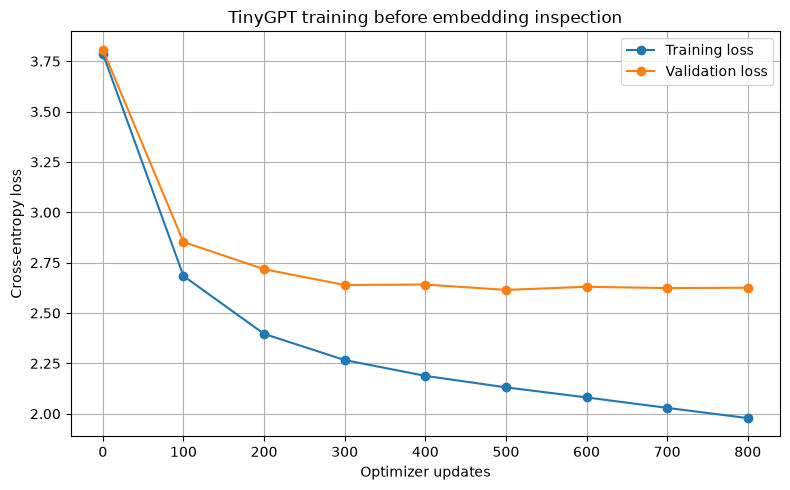

In [7]:
import matplotlib.pyplot as plt  # noqa: I001


plt.figure(figsize=(8, 5))
plt.plot(
    training_result.evaluation_steps,
    training_result.training_losses,
    marker="o",
    label="Training loss",
)
plt.plot(
    training_result.evaluation_steps,
    training_result.validation_losses,
    marker="o",
    label="Validation loss",
)
plt.xlabel("Optimizer updates")
plt.ylabel("Cross-entropy loss")
plt.title("TinyGPT training before embedding inspection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Training loss falls throughout the retained run, while validation loss improves most by about step `500` and then changes little.

The model has learned the training task, but the growing train-validation gap also reflects the limits of this tiny dataset.

## Extract and validate the table

Recent notebooks name the module `token_embedding`, so its trainable matrix is `model.token_embedding.weight`.

`detach().clone()` creates a stable inspection snapshot that is disconnected from gradients and future parameter mutation.

In [8]:
embedding_table = model.token_embedding.weight.detach().clone()
embedding_vocabulary_size, embedding_dimension = embedding_table.shape

print("Embedding table shape:", tuple(embedding_table.shape))
print("Vocabulary rows:", embedding_vocabulary_size)
print("Values per row:", embedding_dimension)
print("Model vocabulary size:", model.vocabulary_size)

assert embedding_vocabulary_size == model.vocabulary_size == vocabulary_size
assert torch.equal(embedding_table, training_result.trained_embedding_table)

Embedding table shape: (35, 64)
Vocabulary rows: 35
Values per row: 64
Model vocabulary size: 35


## Retrieve one row and one lookup batch

Indexing row `token_to_token_id('A')` returns one 64-value vector.

Calling the embedding module on `[batch, time]` IDs adds an embedding dimension and returns `[batch, time, embedding]`.

In [9]:
selected_token = "A"
selected_token_id = token_to_token_id(selected_token)
selected_embedding = embedding_table[selected_token_id]
lookup_ids = torch.tensor([[selected_token_id, token_to_token_id("l")]])
lookup_vectors = model.token_embedding(lookup_ids).detach()

print("Selected token:", repr(selected_token))
print("Selected token ID:", selected_token_id)
print("Selected vector shape:", tuple(selected_embedding.shape))
print("First 8 values:", selected_embedding[:8])
print("Lookup output shape:", tuple(lookup_vectors.shape))

assert torch.equal(lookup_vectors[0, 0], selected_embedding)

Selected token: 'A'
Selected token ID: 7
Selected vector shape: (64,)
First 8 values: tensor([-1.3746,  0.1124, -0.4396,  0.7345,  0.6461,  0.4971,  0.0845,  0.3922])
Lookup output shape: (1, 2, 64)


## Measure norms and movement

The norm describes vector magnitude, while movement is the Euclidean distance between a token's initialized and trained rows.

Neither quantity is an importance score.

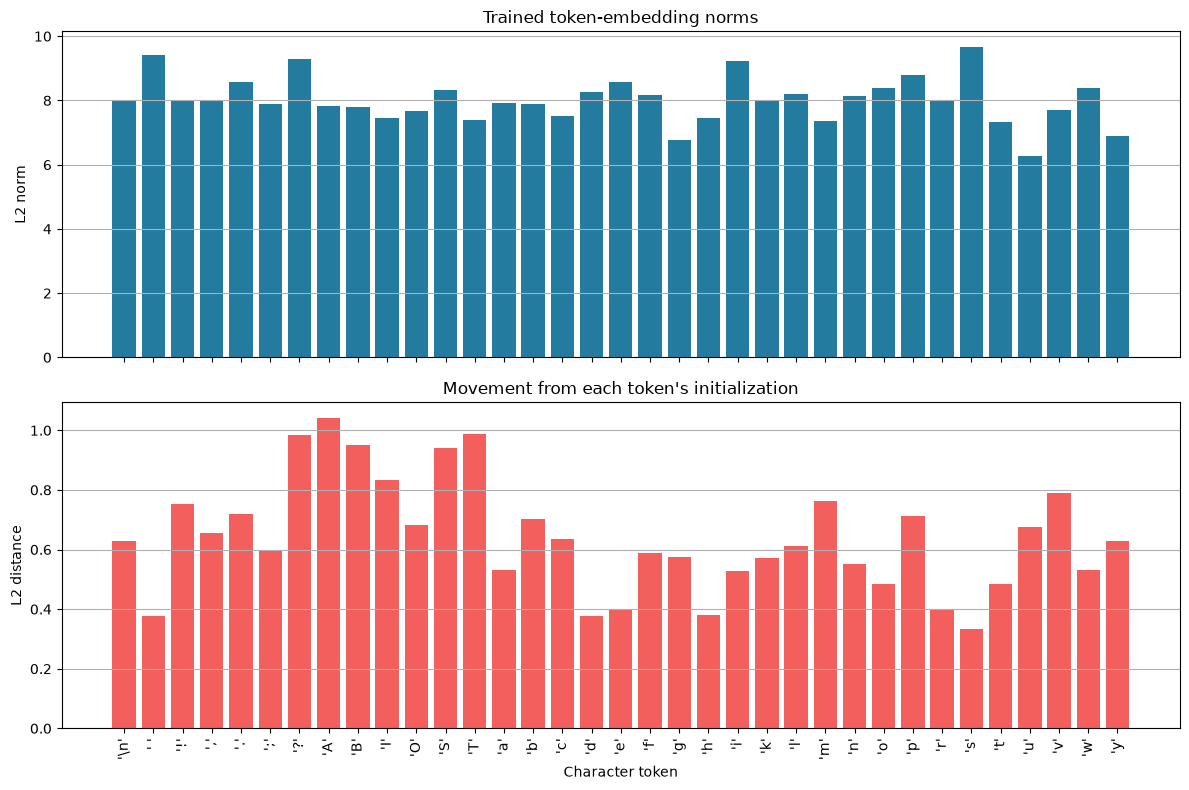

Largest movement token: 'A'
Largest movement: 1.0418649911880493


In [10]:
initial_embedding_table = training_result.initial_embedding_table
embedding_norms = embedding_table.norm(dim=1)
embedding_movements = (embedding_table - initial_embedding_table).norm(dim=1)
token_labels = [repr(token_id_to_token(index)) for index in range(vocabulary_size)]

figure, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].bar(token_labels, embedding_norms.tolist(), color="#247ba0")
axes[0].set_ylabel("L2 norm")
axes[0].set_title("Trained token-embedding norms")
axes[0].grid(axis="y")
axes[1].bar(token_labels, embedding_movements.tolist(), color="#f25f5c")
axes[1].set_xlabel("Character token")
axes[1].set_ylabel("L2 distance")
axes[1].set_title("Movement from each token's initialization")
axes[1].tick_params(axis="x", rotation=90)
axes[1].grid(axis="y")
figure.tight_layout()
plt.show()

largest_movement_id = int(embedding_movements.argmax().item())
print("Largest movement token:", repr(token_id_to_token(largest_movement_id)))
print("Largest movement:", float(embedding_movements.max().item()))

The retained output identifies uppercase `'A'` as the row with the largest Euclidean movement.

That observation does not make `'A'` the most important token or identify why its optimizer trajectory was largest.

## Compute cosine similarity

Cosine similarity is the dot product of unit-normalized vectors and usually lies between `-1` and `1` up to floating-point error.

It ignores vector length, so it answers a different question from Euclidean distance.

In [11]:
def normalize_embedding_table(table: torch.Tensor) -> torch.Tensor:
    if table.ndim != 2:
        raise ValueError("Embedding table must be two-dimensional.")
    normalized_table: torch.Tensor = table / table.norm(dim=1, keepdim=True).clamp_min(
        1e-12
    )
    return normalized_table


normalized_embeddings = normalize_embedding_table(embedding_table)
cosine_similarity_matrix = normalized_embeddings @ normalized_embeddings.T
uppercase_a_id = token_to_token_id("A")
lowercase_a_id = token_to_token_id("a")
uppercase_lowercase_similarity = float(
    cosine_similarity_matrix[uppercase_a_id, lowercase_a_id].item()
)

print("Similarity matrix shape:", tuple(cosine_similarity_matrix.shape))
print("cosine('A', 'a'):", uppercase_lowercase_similarity)
print(
    "Diagonal near 1:",
    torch.allclose(cosine_similarity_matrix.diag(), torch.ones(vocabulary_size)),
)

assert torch.allclose(
    cosine_similarity_matrix.diag(), torch.ones(vocabulary_size), atol=1e-6
)

Similarity matrix shape: (35, 35)
cosine('A', 'a'): 0.20137405395507812
Diagonal near 1: True


## Find nearest neighbors safely

The helper validates the requested count, normalizes every row, and excludes the query token by replacing its self-similarity before `topk`.

In [12]:
from collections.abc import Callable


def find_nearest_neighbors(
    token: str,
    table: torch.Tensor,
    token_to_id: Callable[[str], int],
    id_to_token: Callable[[int], str],
    number_of_neighbors: int = 5,
) -> list[tuple[str, int, float]]:
    if not 1 <= number_of_neighbors < table.shape[0]:
        raise ValueError("Neighbor count must be between 1 and vocabulary_size - 1.")
    query_id = token_to_id(token)
    normalized_table = normalize_embedding_table(table)
    similarities = normalized_table @ normalized_table[query_id]
    similarities = similarities.clone()
    similarities[query_id] = -float("inf")
    neighbor_similarities, neighbor_ids = torch.topk(
        similarities, k=number_of_neighbors
    )
    return [
        (id_to_token(neighbor_id), neighbor_id, similarity)
        for neighbor_id, similarity in zip(
            neighbor_ids.tolist(), neighbor_similarities.tolist(), strict=True
        )
    ]


selected_tokens = ["A", "a", "e", " ", "."]
for query_token in selected_tokens:
    print("\nNearest trained neighbors for", repr(query_token))
    for neighbor_token, neighbor_id, similarity in find_nearest_neighbors(
        query_token,
        embedding_table,
        token_to_token_id,
        token_id_to_token,
        number_of_neighbors=5,
    ):
        print(
            f"  {neighbor_token!r:>5} | id={neighbor_id:>2} | cosine={similarity:>7.4f}"
        )


Nearest trained neighbors for 'A'
    'm' | id=24 | cosine= 0.2342
    'a' | id=13 | cosine= 0.2014
    'r' | id=28 | cosine= 0.1736
    'l' | id=23 | cosine= 0.1594
    'h' | id=20 | cosine= 0.0877

Nearest trained neighbors for 'a'
    'A' | id= 7 | cosine= 0.2014
    'T' | id=12 | cosine= 0.1875
    'm' | id=24 | cosine= 0.1716
    'O' | id=10 | cosine= 0.1479
    'v' | id=32 | cosine= 0.1110

Nearest trained neighbors for 'e'
    'S' | id=11 | cosine= 0.1845
    'n' | id=25 | cosine= 0.1795
    't' | id=30 | cosine= 0.1521
    '?' | id= 6 | cosine= 0.1313
    ';' | id= 5 | cosine= 0.1040

Nearest trained neighbors for ' '
    'w' | id=33 | cosine= 0.3418
    'f' | id=18 | cosine= 0.2111
    'I' | id= 9 | cosine= 0.1757
    'p' | id=27 | cosine= 0.1587
    ',' | id= 3 | cosine= 0.1403

Nearest trained neighbors for '.'
    'k' | id=22 | cosine= 0.2228
    '?' | id= 6 | cosine= 0.2016
   '\n' | id= 0 | cosine= 0.1470
    'g' | id=19 | cosine= 0.1207
    'y' | id=34 | cosine= 0.1163


Every finite vocabulary has nearest neighbors under cosine similarity, even when its vectors are random.

The ranking becomes evidence of learned structure only when it shows repeatable organization beyond an appropriate baseline.

## Compare with the same random initialization

The saved initial table is a stronger baseline than generating unrelated random values because token IDs, shape, initialization distribution, and model seed all match exactly.

In [13]:
for query_token in selected_tokens:
    initial_neighbors = find_nearest_neighbors(
        query_token,
        initial_embedding_table,
        token_to_token_id,
        token_id_to_token,
        number_of_neighbors=3,
    )
    trained_neighbors = find_nearest_neighbors(
        query_token,
        embedding_table,
        token_to_token_id,
        token_id_to_token,
        number_of_neighbors=3,
    )
    initial_labels = [token for token, _, _ in initial_neighbors]
    trained_labels = [token for token, _, _ in trained_neighbors]
    print(
        f"{query_token!r:>3} | initial {initial_labels!r:<22} | "
        f"trained {trained_labels!r}"
    )

'A' | initial ['m', 'a', 'r']        | trained ['m', 'a', 'r']
'a' | initial ['T', 'A', 'm']        | trained ['A', 'T', 'm']
'e' | initial ['S', 'n', 't']        | trained ['S', 'n', 't']
' ' | initial ['w', 'f', 'I']        | trained ['w', 'f', 'I']
'.' | initial ['k', '?', '\n']       | trained ['k', '?', '\n']


The selected top-three neighbor identities remain the same after training, with only some order changes.

This result shows that measurable vector movement did not substantially reorganize these local rankings and that initialization still dominates this small experiment.

## Project both tables through one PCA basis

Principal component analysis finds directions of high variance, not semantic axes.

Fitting separate projections would rotate or reflect each plot independently, so this helper fits one basis to the concatenated normalized initial and trained tables.

Using normalized rows makes the source geometry consistent with the cosine comparisons, although a 2D projection still distorts most pairwise relationships.

In [14]:
def project_embedding_tables_to_shared_2d(
    first_table: torch.Tensor,
    second_table: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    if first_table.shape != second_table.shape:
        raise ValueError("Embedding tables must have matching shapes.")
    first_normalized = normalize_embedding_table(first_table)
    second_normalized = normalize_embedding_table(second_table)
    combined = torch.cat([first_normalized, second_normalized], dim=0)
    center = combined.mean(dim=0, keepdim=True)
    centered = combined - center
    _, singular_values, right_singular_vectors = torch.linalg.svd(
        centered, full_matrices=False
    )
    basis = right_singular_vectors[:2].T
    first_projection = (first_normalized - center) @ basis
    second_projection = (second_normalized - center) @ basis
    explained_fraction = (
        singular_values.square()[:2].sum() / singular_values.square().sum()
    )
    return first_projection, second_projection, explained_fraction


initial_projection, trained_projection, explained_fraction = (
    project_embedding_tables_to_shared_2d(
        initial_embedding_table,
        embedding_table,
    )
)
print("Projection shape:", tuple(trained_projection.shape))
print("Variance retained by two dimensions:", float(explained_fraction.item()))

Projection shape: (35, 2)
Variance retained by two dimensions: 0.14702053368091583


## Plot initial and trained embeddings

Both panels use the same axes and position-matched token labels, so coordinate shifts are directly comparable within this fitted projection.

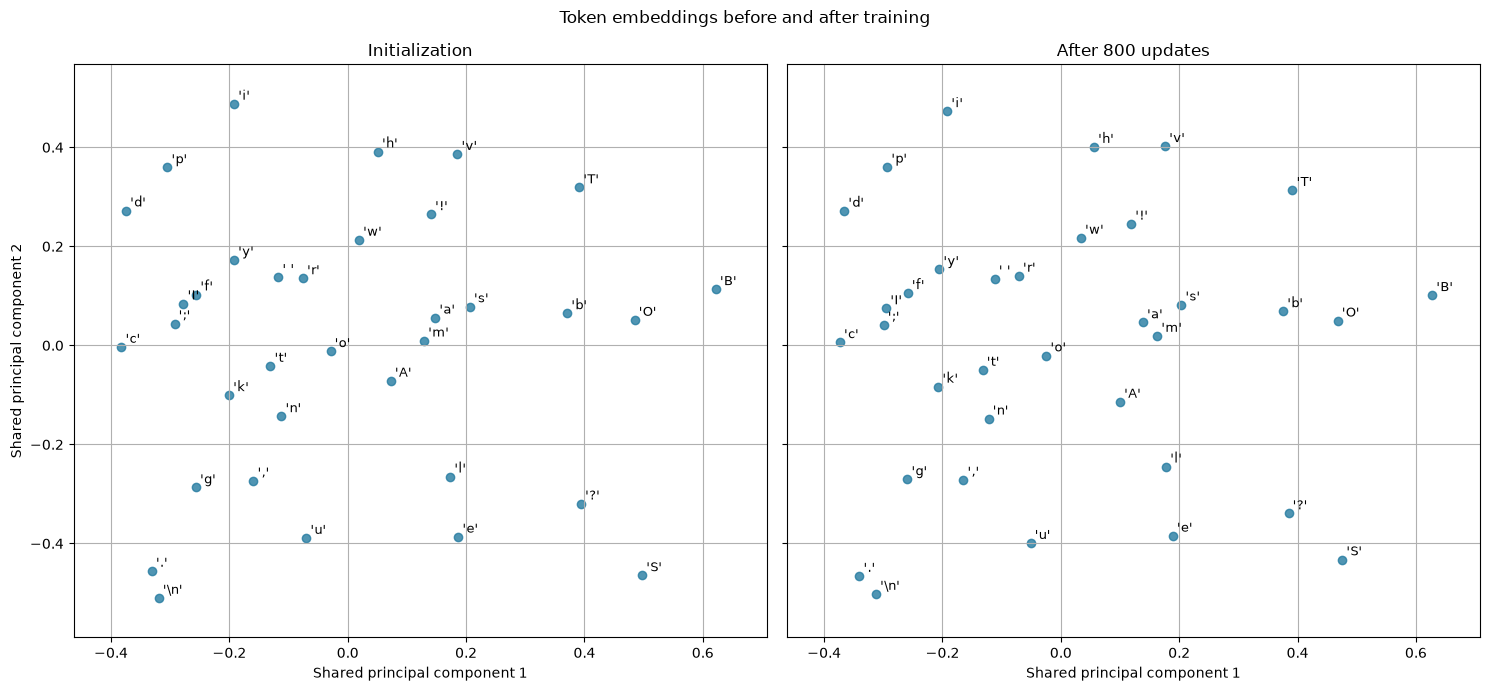

In [15]:
def plot_embedding_projection_comparison(
    initial_projection: torch.Tensor,
    trained_projection: torch.Tensor,
) -> None:
    combined_projection = torch.cat([initial_projection, trained_projection], dim=0)
    x_min, y_min = combined_projection.min(dim=0).values.tolist()
    x_max, y_max = combined_projection.max(dim=0).values.tolist()
    x_padding = 0.08 * max(x_max - x_min, 1e-6)
    y_padding = 0.08 * max(y_max - y_min, 1e-6)
    figure, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True)
    for axis, projection, title in zip(
        axes,
        [initial_projection, trained_projection],
        ["Initialization", "After 800 updates"],
        strict=True,
    ):
        x_values = projection[:, 0].tolist()
        y_values = projection[:, 1].tolist()
        axis.scatter(x_values, y_values, color="#247ba0", alpha=0.8)
        for token_id, (x_value, y_value) in enumerate(
            zip(x_values, y_values, strict=True)
        ):
            axis.annotate(
                repr(token_id_to_token(token_id)),
                (x_value, y_value),
                fontsize=9,
                xytext=(3, 3),
                textcoords="offset points",
            )
        axis.set_xlim(x_min - x_padding, x_max + x_padding)
        axis.set_ylim(y_min - y_padding, y_max + y_padding)
        axis.set_xlabel("Shared principal component 1")
        axis.set_title(title)
        axis.grid(True)
    axes[0].set_ylabel("Shared principal component 2")
    figure.suptitle("Token embeddings before and after training")
    figure.tight_layout()
    plt.show()


plot_embedding_projection_comparison(initial_projection, trained_projection)

The retained projection captures only about `14.7%` of variance in the concatenated normalized tables, so most variation is absent from the figure.

Visual proximity should be checked against full-dimensional cosine similarity before it is described as a neighbor relationship.

## Compare token frequency with movement

Frequency counts opportunities for a token row to receive direct input-embedding gradients, but context, gradient direction, AdamW scaling, and weight decay also affect movement.

The plot is descriptive rather than a claim that frequency alone causes displacement.

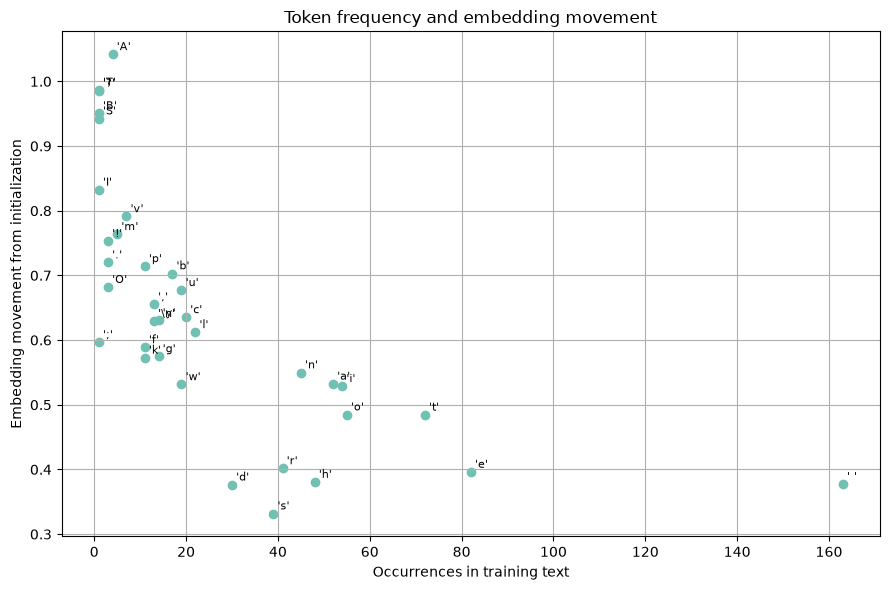

In [16]:
token_frequencies = torch.bincount(training_token_ids, minlength=vocabulary_size).to(
    torch.float32
)

plt.figure(figsize=(9, 6))
plt.scatter(token_frequencies.tolist(), embedding_movements.tolist(), color="#70c1b3")
for token_id in range(vocabulary_size):
    plt.annotate(
        repr(token_id_to_token(token_id)),
        (
            float(token_frequencies[token_id].item()),
            float(embedding_movements[token_id].item()),
        ),
        fontsize=8,
        xytext=(3, 3),
        textcoords="offset points",
    )
plt.xlabel("Occurrences in training text")
plt.ylabel("Embedding movement from initialization")
plt.title("Token frequency and embedding movement")
plt.grid(True)
plt.tight_layout()
plt.show()

## Distinguish input and output token vectors

The output layer also has one row per vocabulary token, but each row scores a hidden state rather than encoding an input ID.

This model does not tie the two matrices, so equal shapes do not imply equal values or equal roles.

In [17]:
output_vectors = model.output_layer.weight.detach()
same_token_input_output_cosine = float(
    torch.nn.functional.cosine_similarity(
        embedding_table[selected_token_id],
        output_vectors[selected_token_id],
        dim=0,
    ).item()
)

print("Input embedding shape:", tuple(embedding_table.shape))
print("Output weight shape:", tuple(output_vectors.shape))
print(
    "Input and output storage is shared:",
    model.token_embedding.weight.data_ptr() == model.output_layer.weight.data_ptr(),
)
print("Same-token input/output cosine:", same_token_input_output_cosine)

assert embedding_table.shape == output_vectors.shape
assert model.token_embedding.weight.data_ptr() != model.output_layer.weight.data_ptr()

Input embedding shape: (35, 64)
Output weight shape: (35, 64)
Input and output storage is shared: False
Same-token input/output cosine: -0.09479483962059021


## Apply the tools to subword models

The geometry functions accept tensors and do not depend on character tokenization.

A subword model needs lookup functions backed by the exact tokenizer used during training, such as `tokenizer.token_to_id` and `tokenizer.id_to_token`.

Subword neighbors may be easier to read than character neighbors, but model size, data, frequency, and projection caveats still apply.

## Verify the experiment contracts

These checks cover update count, checkpoints, snapshot independence, finite values, normalization, and the shared projection shape.

In [18]:
expected_steps = list(range(0, embedding_config["training_steps"] + 1, 100))
assert training_result.optimizer_updates == embedding_config["training_steps"]
assert training_result.evaluation_steps == expected_steps
assert embedding_table.data_ptr() != model.token_embedding.weight.data_ptr()
assert torch.isfinite(embedding_table).all()
assert torch.isfinite(cosine_similarity_matrix).all()
assert tuple(initial_projection.shape) == (vocabulary_size, 2)
assert tuple(trained_projection.shape) == (vocabulary_size, 2)
assert 0.0 < float(explained_fraction.item()) <= 1.0
assert all(
    math.isfinite(loss)
    for loss in training_result.training_losses + training_result.validation_losses
)
print("All training and embedding-inspection contracts passed.")

All training and embedding-inspection contracts passed.


## Common mistakes

- Using a stale attribute such as `token_embedding_table` fails when the current model names the module `token_embedding`.

- Calling a nearest neighbor semantically equivalent confuses vector geometry with meaning.

- Forgetting to exclude self-similarity returns the query as its own nearest neighbor.

- Comparing separately fitted 2D projections treats unrelated axes as if they were aligned.

- Reading PCA axes as learned concepts assigns meaning to directions chosen only for variance.

- Judging full-dimensional cosine distance from a 2D plot ignores projection distortion.

- Comparing trained vectors only with unrelated random values wastes the stronger baseline provided by the model's own initialization.

- Treating embedding norm or movement as token importance overstates descriptive statistics.

- Confusing input embeddings with contextual hidden states ignores most of the network.

## Takeaways

- `model.token_embedding.weight` has one learned row per vocabulary token.

- Embedding lookup changes `[batch, time]` token IDs into `[batch, time, embedding]` vectors.

- Norm, Euclidean movement, and cosine similarity measure different properties.

- Nearest-neighbor rankings require a baseline because random initialization also has nearest neighbors.

- A shared PCA basis permits a fair visual before-and-after comparison, but two dimensions still discard most geometry.

- Tiny character embeddings can be noisy and should not support broad semantic claims.

## What comes next

Input embeddings describe the model before context is processed, while hidden-state inspection can measure how representations change after each Transformer block.

That comparison extends interpretability from static token rows to context-dependent activations.